# Handson 6 : Analyzing a simulation of surface convection

#### In this handson we will analyze a simulation of a surface layer of a star. The equations of magnetohydrodynamics are solved, together with equation of state and radiative transfer equation, to produce a box with values of various physical parameters. 

#### Today we will visualize these parameters and calculate some quantities 

In [1]:
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
atmos = np.load("/home/milic/data/scratch/exercise_63000.npy")

In [3]:
atmos.shape

(6, 512, 512, 480)

#### The dimensions are 6, 512, 512, 480. First number denotes the number of physical parameters I stored: 
0 - temperature 

1 - gas pressure 

2 - internal energy 

3 - vx

4 - vy 

5 - vz

#### Next three dimensions are x,y,z. 

#### For practice, plot the variation of temperature with depth for one value of x and y. 

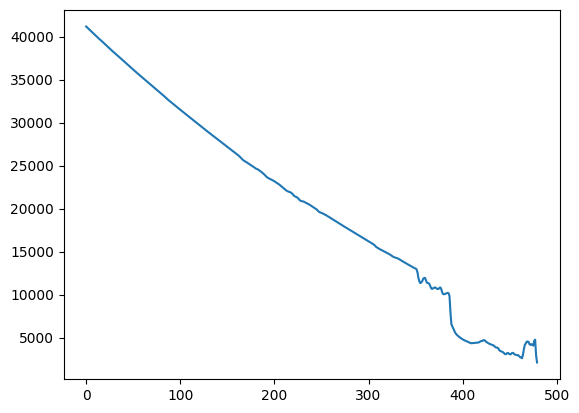

In [4]:
plt.plot(atmos[0,123,321,:])

This is not temperature vs the depth index, z-spacing of the simulation is 16 km and x and y are 48 km. So: 

In [5]:
NX, NY, NZ = atmos[0].shape
x = np.arange(NX) * 48.0
y = np.arange(NY) * 48.0
z = np.arange(NZ) * 16.0

Text(0, 0.5, 'T [K]')

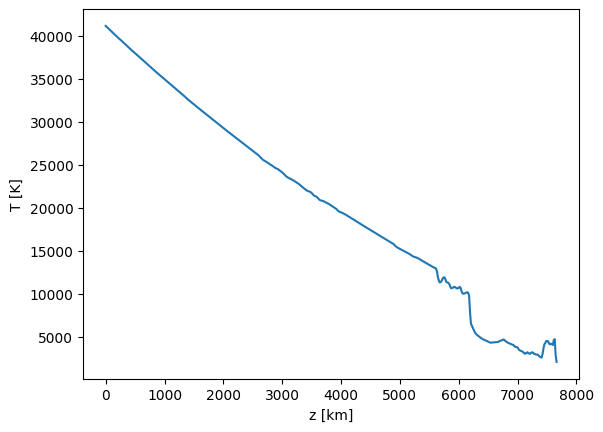

In [6]:
plt.plot(z,atmos[0,123,321,:])
plt.xlabel("z [km]")
plt.ylabel("T [K]")

#### To learn a bit more let's plot the temperature averaged over x and y: 

In [7]:
mean_atmos = np.mean(atmos, axis=(1,2))

Text(0, 0.5, 'T [K]')

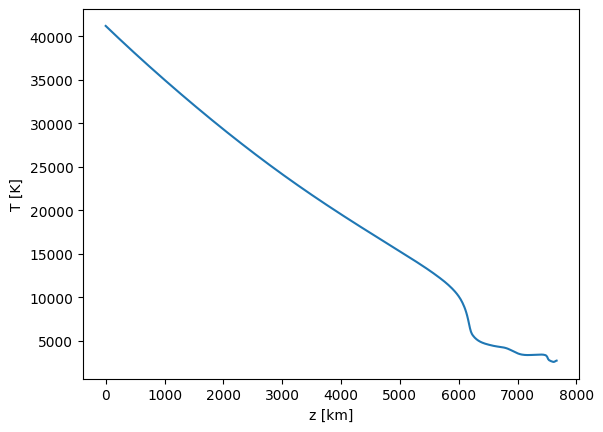

In [8]:
plt.plot(z,mean_atmos[0,:])
plt.xlabel("z [km]")
plt.ylabel("T [K]")

### Answer the following questions (material for the class): 

### 1) Why is temperature monotonically decreasing? Did you expect that? 

### 2) Why does it drop so rapidly around 60000 km? 

### 3) How would you define the Solar surface from this plot? 

### 4) How can you track the temperature variation in all three dimensions? 

### 5) Estimate the effective temperature of this "star" ? 

## 2D plots of physical quantities at different heights: 

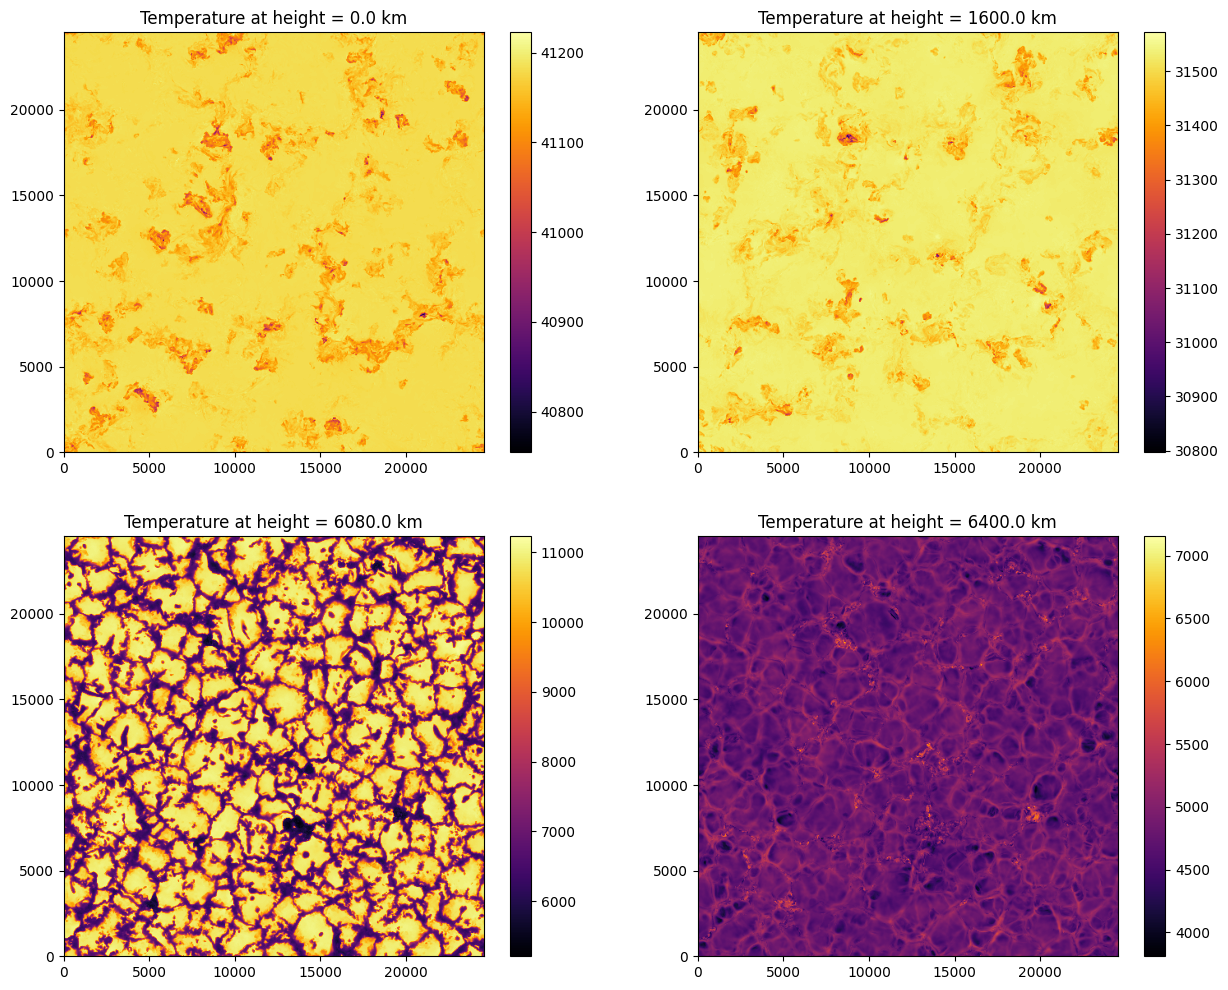

In [17]:
# Temperature:

heights = [0, 100, 380, 400]
plt.figure(figsize=[15,12]) 
for i in range(0,4):
    plt.subplot(2,2,i+1)
    plt.imshow(atmos[0,:,:,heights[i]].T, origin='lower', cmap = 'inferno', extent = [x[0],x[-1],y[0],y[-1]])
    plt.title("Temperature at height = "+str(z[heights[i]])+ " km")
    plt.colorbar()

## 5a) What looks the most like the surface? 

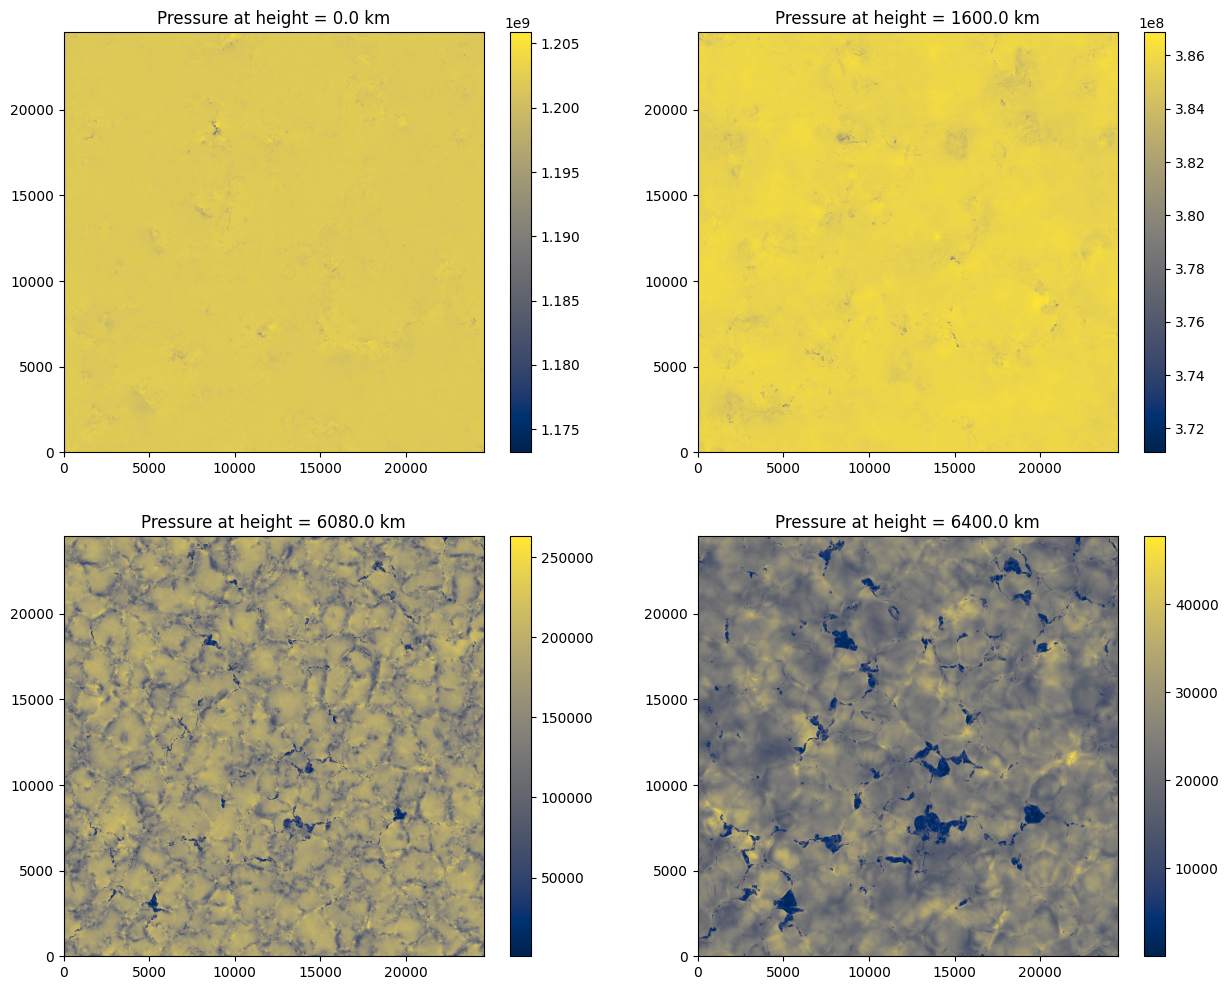

In [18]:
# Pressure

heights = [0, 100, 380, 400]
plt.figure(figsize=[15,12]) 
for i in range(0,4):
    plt.subplot(2,2,i+1)
    plt.imshow(atmos[1,:,:,heights[i]].T, origin='lower', cmap = 'cividis', extent = [x[0],x[-1],y[0],y[-1]])
    plt.title("Pressure at height = "+str(z[heights[i]])+ " km")
    plt.colorbar()

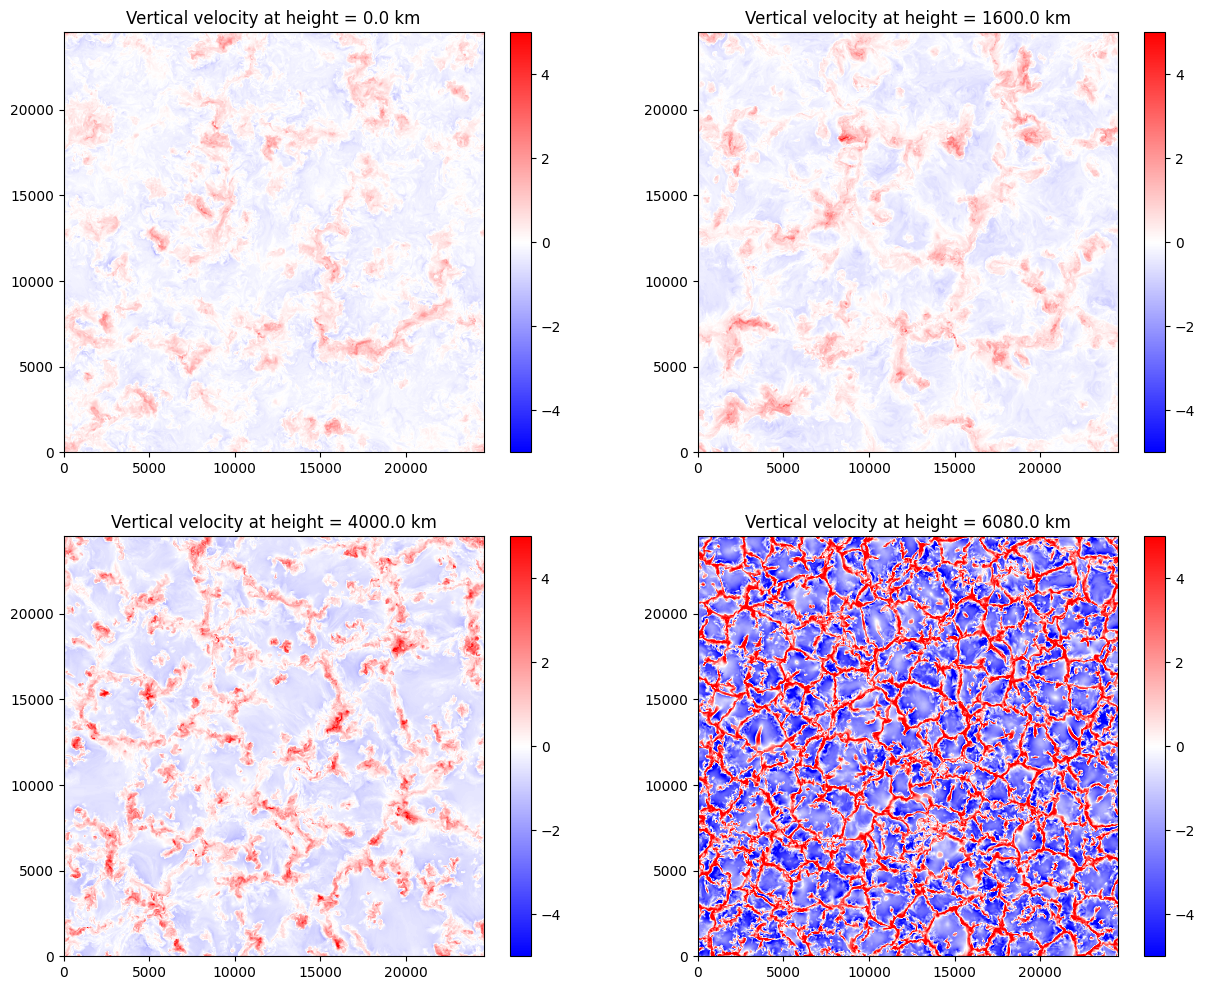

In [25]:
# Vertical velocity

heights = [0, 100, 250, 380]
plt.figure(figsize=[15,12]) 
for i in range(0,4):
    plt.subplot(2,2,i+1)
    plt.imshow(atmos[5,:,:,heights[i]].T/-1E5, origin='lower', cmap = 'bwr', extent = [x[0],x[-1],y[0],y[-1]],vmin=-5,vmax=5)
    plt.title("Vertical velocity at height = "+str(z[heights[i]])+ " km")
    plt.colorbar()
plt.savefig("velocities_muram.png")